# Computer Vision — Part 2 · Practical Notebook
## STUDENT VERSION — fill in every `TODO`

**Companion lab for the lecture: Classic Networks → ResNets → 1×1 Convs → Transfer Learning → Data Augmentation → Vision Transformers → Evaluation → Model Persistence**

---

This notebook is deliberately **practical**. We focus on the workflows you will actually use in real projects and in industry:

- We **use pretrained models** from `torchvision` instead of re-implementing LeNet / AlexNet / VGG from scratch. Nobody trains these from zero anymore — you download weights.
- We do a **real transfer-learning fine-tune** on a real dataset. This is the single most common deep-learning-for-vision task in the wild.
- We build a **production-style `transforms` augmentation pipeline**.
- We **compare a CNN (ResNet) against a Vision Transformer (ViT)** and fine-tune both — the architecture family powering most modern systems.
- We finish with the two skills that turn a trained model into something usable: rigorous **training/validation/evaluation** (per-class accuracy, confusion matrices, reading the train/val gap) and **saving and reusing trained models** (checkpointing with `state_dict()`, reloading, and verifying the reload matches).

### How to use this notebook

Cells marked **`# TODO`** are yours to complete — that is where the learning happens. Each one gives you the surrounding structure, the expected output shape, and hints; you write the technique. Cells *without* a TODO (setup, dataset download, plotting helpers) are given to you complete — read them, run them, but you do not need to edit them.

Work top to bottom: later cells depend on variables and helpers defined earlier.

> **How to run this:** Easiest is Google Colab with a GPU (`Runtime → Change runtime type → GPU`). It also runs on a local machine with PyTorch installed; CPU works but the fine-tuning sections will be slow.


## 1 · Setup & device

We install (if needed) and import everything once. The `device` line is the
standard idiom: write code once, run on GPU if available, fall back to CPU.


In [1]:
# If running on Colab, torch & torchvision are already installed.
# Uncomment the next line if you are on a fresh local environment.
# !pip install torch torchvision matplotlib --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import models, transforms, datasets
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# The standard device idiom — every real PyTorch project starts like this.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version :", torch.__version__)
print("Using device    :", device)
if device.type == "cuda":
    print("GPU             :", torch.cuda.get_device_name(0))


PyTorch version : 2.11.0+cu128
Using device    : cuda
GPU             : Tesla T4


## 2 · Activations — a 2-minute visual sanity check

> *Lecture recap:* an activation is a **non-linear, differentiable** function
> placed between layers. Non-linear so the network can't collapse into one
> linear layer; differentiable so backprop has gradients to flow.

In practice you rarely *implement* activations — you pick one. But you should
be able to *see* why some choices cause trouble:

- **ReLU** — the default. Cheap, no saturation on the positive side. Risk:
  *dying ReLU* (negative inputs → 0 gradient → neuron stops learning).
- **Leaky ReLU** — small slope for negatives, fixes dying ReLU.
- **Sigmoid / tanh** — saturate at the tails → *vanishing gradients*. Avoid in
  hidden layers; sigmoid still fine as a final layer for binary probability.

Let's just plot them and their gradients.


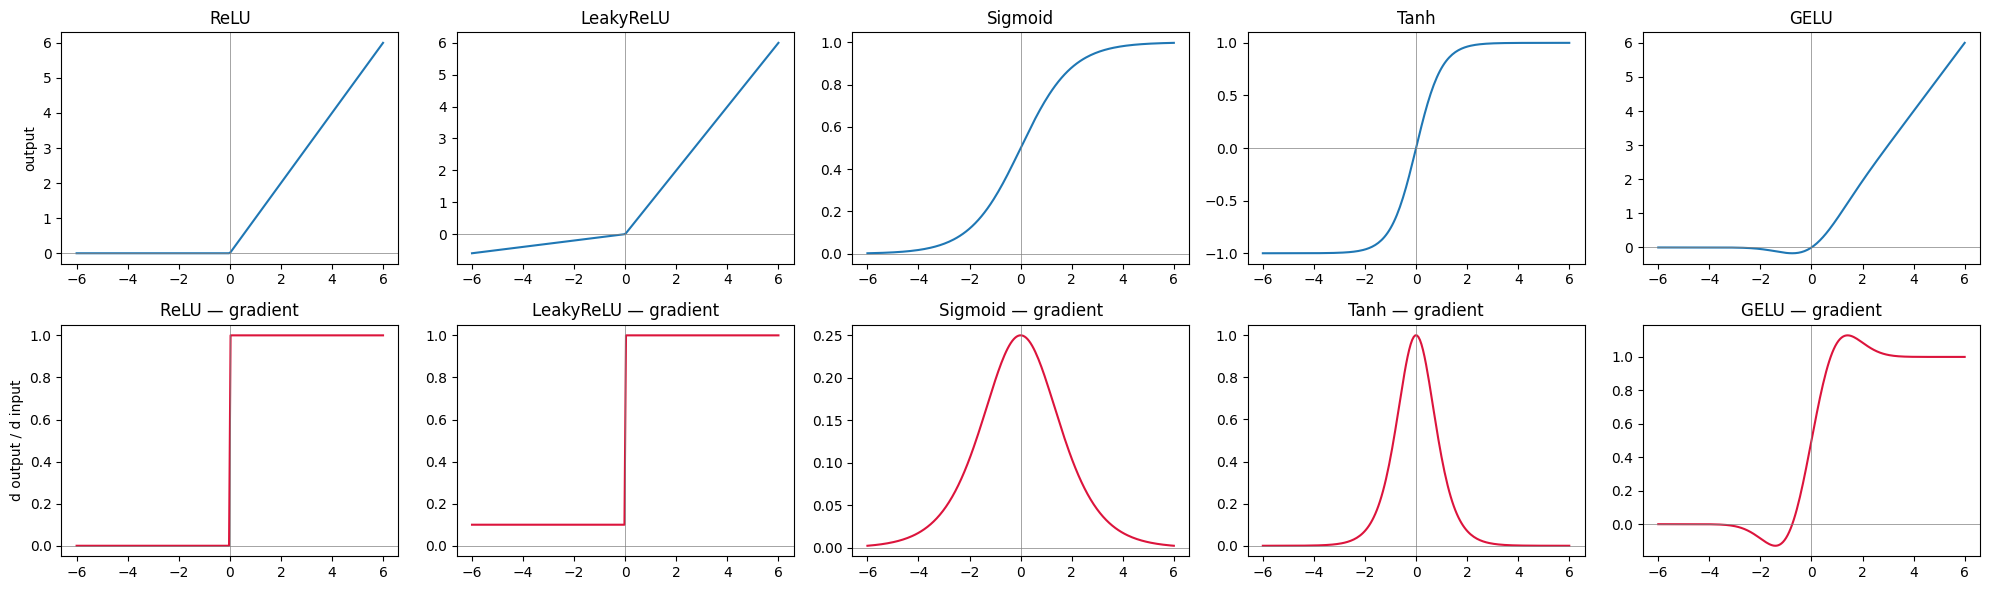

In [2]:
# TODO 2.1 -- Build the activation comparison.
#
# Fill in the `acts` dictionary so it maps each activation NAME to a
# callable that applies it. The plotting code below is given; it expects
# `acts` to contain exactly these four entries:
#
#   "ReLU"      -> F.relu
#   "LeakyReLU" -> leaky ReLU with negative_slope=0.1
#   "Sigmoid"   -> torch.sigmoid
#   "Tanh"      -> torch.tanh
#
# Hint: LeakyReLU needs an argument, so wrap it in a lambda:
#   lambda x: F.leaky_relu(x, negative_slope=0.1)
#
# Once it runs, ALSO add a fifth entry "GELU" -> F.gelu and re-run.
# GELU is the activation used inside Transformers / ViT (Section 8), so you
# will meet it again. In a comment below, describe in one sentence how GELU's
# gradient near z = 0 differs from ReLU's.

z = torch.linspace(-6, 6, 200, requires_grad=True)

acts = {
    "ReLU":      F.relu,                                         # "ReLU":      ...,
    "LeakyReLU": lambda x: F.leaky_relu(x, negative_slope=0.1), # "LeakyReLU": ...,
    "Sigmoid":   torch.sigmoid,                                 # "Sigmoid":   ...,
    "Tanh":      torch.tanh,                                    # "Tanh":      ...,
    "GELU":      F.gelu,



}

# --- given: plotting (do not edit) ---
assert len(acts) >= 4, "Fill in the acts dictionary first."
fig, axes = plt.subplots(2, len(acts), figsize=(4 * len(acts), 6))
for col, (name, fn) in enumerate(acts.items()):
    y = fn(z)
    grad, = torch.autograd.grad(y.sum(), z, retain_graph=True)
    axes[0, col].plot(z.detach(), y.detach())
    axes[0, col].set_title(f"{name}")
    axes[0, col].axhline(0, color="gray", lw=.5); axes[0, col].axvline(0, color="gray", lw=.5)
    axes[1, col].plot(z.detach(), grad.detach(), color="crimson")
    axes[1, col].set_title(f"{name} — gradient")
    axes[1, col].axhline(0, color="gray", lw=.5); axes[1, col].axvline(0, color="gray", lw=.5)
axes[0, 0].set_ylabel("output"); axes[1, 0].set_ylabel("d output / d input")
plt.tight_layout(); plt.show()

# TODO: one sentence -- how does GELU's gradient near z = 0 differ from ReLU's?
# Your answer:


**Read the bottom row — that's the row that matters for training.**
Notice the sigmoid and tanh gradients are nearly flat (≈0) once you move away from the centre. That flatness *is* the vanishing-gradient problem. ReLU's gradient is a clean 1 on the positive side — that is why it became the default.


## 3 · Convolution mechanics: shapes, stride, padding, pooling

> *Lecture recap:* a filter slides over the image computing dot products.
> **Stride** = step size (bigger stride → smaller output, less compute).
> **Padding** = a frame around the image so edge pixels get equal attention and
> (with the right padding) the output keeps the input's height/width — that's
> *"same"* padding. **Pooling** downsamples; max-pool keeps the most salient
> value in each window.

The single most useful practical skill here is **predicting output shapes**.
You will debug shape errors constantly. The formula for one spatial dimension:

$$ \text{out} = \left\lfloor \frac{\text{in} + 2p - k}{s} \right\rfloor + 1 $$

where `k` = kernel size, `s` = stride, `p` = padding.


In [3]:
# TODO 3.1a -- Implement the convolution output-size formula.
#
# For one spatial dimension:
#     out = floor( (in + 2*p - k) / s ) + 1
# where k = kernel size, s = stride, p = padding.
# Use integer floor division (//).

def conv_out(in_size, k, s, p):
    """Output spatial size of a conv/pool layer along one dimension."""
    # TODO: return the formula above
    return ((in_size + 2 * p - k) // s) + 1

# --- given: sanity-check the formula against PyTorch itself ---
x = torch.randn(1, 3, 32, 32)   # (batch, channels, H, W) -- a 32x32 RGB image

configs = [
    # (kernel, stride, padding, label)
    (3, 1, 1, "3x3, stride 1, pad 1  -> 'same' padding, size preserved"),
    (3, 1, 0, "3x3, stride 1, pad 0  -> 'valid' padding, shrinks by 2"),
    (3, 2, 1, "3x3, stride 2, pad 1  -> downsample by ~2 (used in ResNet)"),
    (5, 1, 2, "5x5, stride 1, pad 2  -> 'same' padding with a bigger kernel"),
]

print(f"{'config':52s} | formula | actual")
print("-" * 78)
for k, s, p, label in configs:
    layer = nn.Conv2d(3, 8, kernel_size=k, stride=s, padding=p)
    actual = layer(x).shape[-1]
    predicted = conv_out(32, k, s, p)
    flag = "OK" if actual == predicted else "MISMATCH"
    print(f"{label:52s} |   {predicted:3d}   |  {actual:3d}  {flag}")


config                                               | formula | actual
------------------------------------------------------------------------------
3x3, stride 1, pad 1  -> 'same' padding, size preserved |    32   |   32  OK
3x3, stride 1, pad 0  -> 'valid' padding, shrinks by 2 |    30   |   30  OK
3x3, stride 2, pad 1  -> downsample by ~2 (used in ResNet) |    16   |   16  OK
5x5, stride 1, pad 2  -> 'same' padding with a bigger kernel |    32   |   32  OK


Notice that `3x3, stride 1, padding 1` keeps the size at 32 — that's the
**"same" convolution** the lecture mentioned, and it's exactly why ResNet can
add a block's input to its output (the shapes line up).

Now pooling — same formula, no learnable weights:


In [ ]:
feat = torch.randn(1, 8, 32, 32)
pool = nn.MaxPool2d(kernel_size=2, stride=2)   # the classic 2x2 / stride 2
print("before max-pool:", feat.shape)
print("after  max-pool:", pool(feat).shape, " (H and W halved, channels unchanged)")

In [4]:
# TODO 3.1b -- Design the first two layers of a small CNN.
#
# Input is a batch of RGB images of size (N, 3, 224, 224) -- the standard
# ImageNet input size. Choose kernel_size / stride / padding so that:
#   - conv1 outputs 64 channels at spatial size 112x112  (halves H/W)
#   - pool1 then brings it to 56x56
#
# Use your conv_out helper to check the arithmetic BEFORE running the model.
# Hint: this is exactly the ResNet 'stem'. A 7x7 stride-2 conv halves 224
# (what padding keeps it exact?), and a 3x3 stride-2 maxpool with padding 1
# halves it again.

N = 4
x = torch.randn(N, 3, 224, 224)

conv1 = nn.Conv2d(in_channels=3, out_channels=64,
                 kernel_size=7, stride=2, padding=3)   # TODO: 224 -> 112
pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1) # TODO: 112 -> 56

# --- given: verification ---
out = pool1(conv1(x))
print("conv1 out:", conv1(x).shape, "  expected (4, 64, 112, 112)")
print("pool1 out:", out.shape,      "  expected (4, 64, 56, 56)")
assert tuple(out.shape) == (4, 64, 56, 56), "Not matching the target shape yet!"
print("Shapes correct -- this is literally the ResNet 'stem'.")


conv1 out: torch.Size([4, 64, 112, 112])   expected (4, 64, 112, 112)
pool1 out: torch.Size([4, 64, 56, 56])   expected (4, 64, 56, 56)
Shapes correct -- this is literally the ResNet 'stem'.


## 4 · Using pretrained classic networks — the real-world way

> *Lecture recap:* LeNet-5 (1998, ~60k params, digits), AlexNet (2012, ~60M
> params, ReLU + ImageNet), VGG-16 (~138M params, only 3×3 convs). The trend:
> deeper networks, height/width shrink, channel count grows.

**You will almost never implement these from scratch in a real job.** You load
them with pretrained weights. `torchvision.models` gives you the whole zoo with
one line. Let's inspect a few and confirm the lecture's claims about parameter
counts and the shrink-spatial / grow-channels pattern.


In [5]:
# TODO 4.1 -- Inspect the torchvision model zoo.
#
# (a) Implement count_params: return the TOTAL number of scalar parameters
#     in a model. Hint: every tensor p has p.numel(); sum over
#     model.parameters().
# (b) The `zoo` dict is given. Models are loaded with weights=None -- we only
#     want to inspect structure and size here (real weights come in Sec 5 & 8).

def count_params(model):
    # TODO: return the total parameter count
    return sum(p.numel() for p in model.parameters())

# --- given ---
zoo = {
    "AlexNet":   models.alexnet(weights=None),
    "VGG-16":    models.vgg16(weights=None),
    "ResNet-18": models.resnet18(weights=None),
    "ResNet-50": models.resnet50(weights=None),
}

print(f"{'model':12s} | {'parameters':>14s}")
print("-" * 32)
for name, m in zoo.items():
    print(f"{name:12s} | {count_params(m):14,d}")


model        |     parameters
--------------------------------
AlexNet      |     61,100,840
VGG-16       |    138,357,544
ResNet-18    |     11,689,512
ResNet-50    |     25,557,032


VGG-16's ~138M parameters versus ResNet-18's ~11M is a big practical
point: **deeper is not the same as bigger**, and ResNet's design gets *more*
depth with *fewer* parameters. That efficiency is part of why ResNet, not VGG,
is the default backbone today.

Let's *watch* the "spatial shrinks, channels grow" pattern by pushing one image
through ResNet-18 layer by layer:


In [6]:
# TODO 4.2 -- Watch 'spatial shrinks, channels grow' stage by stage.
#
# Build the `stages` list: each entry is (name, module) for one top-level
# stage of ResNet-18, IN ORDER. The model object `resnet` is given.
# The stages, in order, are:
#   1. "conv1 + bn + relu" -- wrap resnet.conv1, resnet.bn1, resnet.relu in
#                              an nn.Sequential so they run as one stage
#   2. "maxpool"  -> resnet.maxpool
#   3. "layer1"   -> resnet.layer1
#   4. "layer2"   -> resnet.layer2
#   5. "layer3"   -> resnet.layer3
#   6. "layer4"   -> resnet.layer4
#   7. "avgpool"  -> resnet.avgpool

resnet = models.resnet18(weights=None).eval()
x = torch.randn(1, 3, 224, 224)

stages = [
    # TODO: fill in the seven (name, module) tuples described above
    ("conv1 + bn + relu", nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)),
    ("maxpool", resnet.maxpool),
    ("layer1", resnet.layer1),
    ("layer2", resnet.layer2),
    ("layer3", resnet.layer3),
    ("layer4", resnet.layer4),
    ("avgpool", resnet.avgpool),
]

# --- given: push the image through and print shapes ---
assert len(stages) == 7, "stages should have exactly 7 entries."
print(f"{'stage':22s} | output shape (N, C, H, W)")
print("-" * 55)
with torch.no_grad():
    for name, stage in stages:
        x = stage(x)
        print(f"{name:22s} | {tuple(x.shape)}")


stage                  | output shape (N, C, H, W)
-------------------------------------------------------
conv1 + bn + relu      | (1, 64, 112, 112)
maxpool                | (1, 64, 56, 56)
layer1                 | (1, 64, 56, 56)
layer2                 | (1, 128, 28, 28)
layer3                 | (1, 256, 14, 14)
layer4                 | (1, 512, 7, 7)
avgpool                | (1, 512, 1, 1)


Read the `H, W` column going down — it shrinks 112 → 56 → 56 → 28 → 14 → 7
→ 1. Read the `C` column — it grows 64 → 64 → 128 → 256 → 512. **Exactly the
lecture's pattern.** The final `avgpool` collapses the 7×7 map to 1×1 — that's
*global average pooling*, the modern replacement for giant fully-connected
layers (this is the "Network in Network" idea from the lecture).


## 5 · ResNet & the residual block

> *Lecture recap:* very deep plain networks train *worse*, not better — signal
> and gradients get "scrambled" by many random weight multiplications. The fix
> is the **skip connection**: `output = F(x) + x`. If a block has nothing useful
> to add, it can easily learn `F(x) ≈ 0` and just pass `x` through (the identity
> function). Skip connections also give gradients a short path back to early
> layers.

Here's a residual block written out — this **is** worth seeing in code once,
because the `+ identity` line is the entire idea:


In [7]:
# TODO 5.1 -- Implement the ResNet basic residual block from scratch.
#
# A basic block has two 3x3 convs plus a skip connection. Complete the four
# blanks. The whole point of ResNet is the line  out = F(x) + identity.
#
# Layer recipe (all already declared for you in __init__):
#   conv1: in_ch -> out_ch, 3x3, stride=stride, padding=1, bias=False
#   conv2: out_ch -> out_ch, 3x3, stride=1,     padding=1, bias=False
#   bn1, bn2: BatchNorm2d(out_ch)
# Note bias=False on the convs: BatchNorm has its own shift (beta), so a
# conv bias right before it is redundant.
#
# forward() must implement, in order:
#   identity = shortcut(x)              # the path that goes AROUND
#   out = relu( bn1( conv1(x) ) )       # the path that goes THROUGH
#   out = bn2( conv2(out) )
#   out = out + identity                # <-- the whole idea of ResNet
#   return relu(out)

class BasicResidualBlock(nn.Module):
    """A ResNet-style basic block: two 3x3 convs + a skip connection."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        # --- given: layer declarations ---
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        # If channels or spatial size change, the skip path needs a 1x1 conv
        # to match dimensions -- the lecture's 'Ws' matrix. (given)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        # TODO: implement the five steps described above
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + identity
        return F.relu(out)

# --- given: quick test ---
b_same = BasicResidualBlock(64, 64, stride=1)
b_down = BasicResidualBlock(64, 128, stride=2)
t = torch.randn(1, 64, 56, 56)
print("input              :", tuple(t.shape))
print("same-shape block   :", tuple(b_same(t).shape), " (unchanged)")
print("downsampling block :", tuple(b_down(t).shape), " (H/W halved, channels doubled)")


input              : (1, 64, 56, 56)
same-shape block   : (1, 64, 56, 56)  (unchanged)
downsampling block : (1, 128, 28, 28)  (H/W halved, channels doubled)


### Why BatchNorm lives in these blocks

> *Lecture recap:* BatchNorm normalizes each layer's activations using
> **batch statistics** during training, then uses **running (whole-training)
> statistics** at test time. It reduces *internal covariate shift*, smooths the
> loss surface, and speeds up training. In PyTorch you just add `nn.BatchNorm2d`
> — the framework tracks the running stats for you.

The one thing you **must** get right in practice: call `model.train()` vs
`model.eval()`. They switch BatchNorm (and Dropout) between the two modes.
Let's prove the modes actually behave differently:


In [8]:
# TODO 5.2 -- Prove BatchNorm behaves differently in train vs eval mode.
#
# `bn` and `sample` are given. `sample` has mean~2, std~5 (NOT normalized).
# Complete the two blanks:
#   (a) put `bn` into TRAINING mode, then run it on `sample`
#   (b) put `bn` into EVAL mode, then run it on `sample`
# Hint: nn.Module has .train() and .eval() methods that switch the mode.
# In train mode BatchNorm normalizes using THIS batch's statistics; in eval
# mode it uses stored running statistics instead.

bn = nn.BatchNorm2d(3)
sample = torch.randn(8, 3, 16, 16) * 5 + 2   # mean~2, std~5 -- not normalized

# (a) TODO: switch bn to training mode
bn.train()
out_train = bn(sample)
print("TRAIN mode  -> uses THIS batch's stats")
print("   output mean ~", round(out_train.mean().item(), 3),
      " std ~", round(out_train.std().item(), 3), " (normalized)")

# (b) TODO: switch bn to eval mode
bn.eval()
out_eval = bn(sample)
print("EVAL mode   -> uses stored running stats (still default here, so ~identity)")
print("   output mean ~", round(out_eval.mean().item(), 3),
      " std ~", round(out_eval.std().item(), 3))
print()
print("Lesson: ALWAYS set model.eval() before validation/inference,")
print("and model.train() before training. Forgetting this is a top-3 real bug.")


TRAIN mode  -> uses THIS batch's stats
   output mean ~ 0.0  std ~ 1.0  (normalized)
EVAL mode   -> uses stored running stats (still default here, so ~identity)
   output mean ~ 1.007  std ~ 2.712

Lesson: ALWAYS set model.eval() before validation/inference,
and model.train() before training. Forgetting this is a top-3 real bug.


In [9]:
# TODO 5.3 -- Stack three BasicResidualBlocks into a tiny network.
#
# Build TinyResNet so that a (N, 3, 32, 32) CIFAR-sized input comes out as
# 64 channels at 8x8 spatial size. You must decide which blocks use stride=2.
#
# Key idea: each stride=2 block halves H and W. 32 -> 8 is a /4 reduction,
# so you need exactly TWO stride-2 blocks. Channels must chain: the out_ch
# of one block must equal the in_ch of the next.
#
# The stem is given. Fill in the three blocks' (in_ch, out_ch, stride):
#   block1: 16 -> 16, keep 32x32   -> what stride?
#   block2: 16 -> 32, downsample   -> what stride?
#   block3: 32 -> 64, downsample   -> what stride?

class TinyResNet(nn.Module):
    def __init__(self):
        super().__init__()
        # --- given: stem ---
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16), nn.ReLU(),
        )
        # TODO: define block1, block2, block3 as BasicResidualBlock(...)
        self.block1 = BasicResidualBlock(16, 16, stride=1)
        self.block2 = BasicResidualBlock(16, 32, stride=2)
        self.block3 = BasicResidualBlock(32, 64, stride=2)

    def forward(self, x):
        # TODO: pass x through stem, then block1, block2, block3; return result
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return x
# --- given: verification ---
net = TinyResNet()
out = net(torch.randn(4, 3, 32, 32))
print("output:", tuple(out.shape), " expected (4, 64, 8, 8)")
assert tuple(out.shape) == (4, 64, 8, 8)
print("Correct! Two stride-2 blocks give the /4 spatial reduction (32 -> 8).")


output: (4, 64, 8, 8)  expected (4, 64, 8, 8)
Correct! Two stride-2 blocks give the /4 spatial reduction (32 -> 8).


## 6 · Transfer learning — fine-tune a pretrained model on a real dataset

> *Lecture recap:* you rarely have enough data to train from scratch. Download
> a network pretrained on ImageNet (1000 classes), **replace the final
> classification layer** with your own, and either (a) **freeze** the rest and
> train only the new head (small dataset), or (b) **fine-tune** more layers
> (larger dataset). Someone else's pretrained weights do the heavy lifting.

**This is the most important section of the notebook** — it's the workflow you
will use again and again. We'll fine-tune a pretrained **ResNet-18** to classify
**ants vs bees** (the classic `hymenoptera` dataset — small, downloads in
seconds, perfect for a lab).


In [10]:
import os, zipfile, urllib.request

# A genuinely tiny real dataset: ~240 train / ~150 val images, 2 classes.
DATA_URL = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
DATA_DIR = "hymenoptera_data"

if not os.path.isdir(DATA_DIR):
    print("Downloading dataset (~45 MB)...")
    urllib.request.urlretrieve(DATA_URL, "hymenoptera_data.zip")
    with zipfile.ZipFile("hymenoptera_data.zip") as z:
        z.extractall(".")
    print("Done.")
else:
    print("Dataset already present.")

for split_name in ["train", "val"]:
    p = os.path.join(DATA_DIR, split_name)
    classes = sorted(os.listdir(p))
    counts = {c: len(os.listdir(os.path.join(p, c))) for c in classes}
    print(f"  {split_name:5s}: {counts}")


Done.
  train: {'ants': 124, 'bees': 121}
  val  : {'ants': 70, 'bees': 83}


### 6.1 — Data pipeline with the *correct* preprocessing

A pretrained model expects its inputs preprocessed **the same way the original
training data was**. For ImageNet models that means: resize to 224×224 and
normalize with ImageNet's channel mean/std. Getting this wrong silently wrecks
accuracy — it's a real, common bug.

Notice the **train** transform also does augmentation (random crop + flip);
the **val** transform does not. You never augment validation data.


In [11]:
# TODO 6.1 -- Build the data transforms and loaders.
#
# A pretrained ImageNet model expects its inputs preprocessed the SAME way
# the original training data was: resize to 224x224 and normalize with
# ImageNet's channel mean/std. Getting this wrong silently wrecks accuracy.
#
# Complete the two transform pipelines:
#
#   train_tf  (WITH augmentation, applied to training images):
#     - transforms.RandomResizedCrop(224)      random crop + scale
#     - transforms.RandomHorizontalFlip()      mirror
#     - transforms.ToTensor()
#     - transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
#
#   val_tf  (NO randomness -- you never augment validation data):
#     - transforms.Resize(256)
#     - transforms.CenterCrop(224)
#     - transforms.ToTensor()
#     - transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
#
# Pass each list of transforms to transforms.Compose([...]).

# ImageNet normalization constants -- memorize these, you'll type them often.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    # TODO: the four TRAIN transforms above
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_tf = transforms.Compose([
    # TODO: the four VAL transforms above
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# --- given: datasets + loaders ---
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"),   val_tf)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)

class_names = train_ds.classes
print("Classes:", class_names)
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")


Classes: ['ants', 'bees']
Train batches: 8  |  Val batches: 5


Let's actually *look* at a batch (always look at your data — another real
habit). We have to undo the normalization for display.


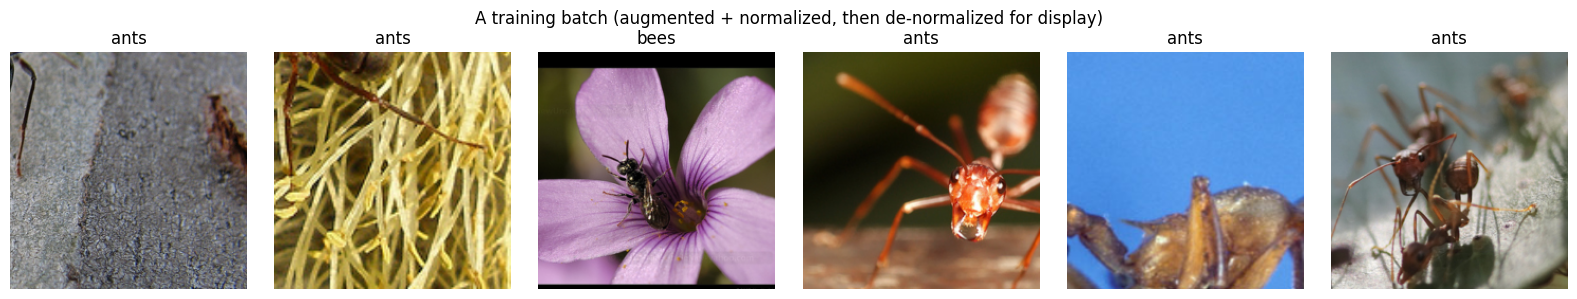

In [12]:
def denormalize(t):
    """Undo ImageNet normalization so we can display the image."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for i in range(6):
    axes[i].imshow(denormalize(imgs[i]).permute(1, 2, 0).numpy())
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis("off")
plt.suptitle("A training batch (augmented + normalized, then de-normalized for display)")
plt.tight_layout(); plt.show()


### 6.2 — Build the transfer-learning model

The recipe in three steps:
1. Load ResNet-18 **with pretrained ImageNet weights**.
2. **Freeze** all existing layers (`requires_grad = False`) — they're already
   good feature extractors.
3. **Replace** the final fully-connected layer (`model.fc`) with a fresh one
   sized for *our* number of classes. New layers are trainable by default.


In [13]:
# TODO 6.2 -- Build the transfer-learning model (feature-extraction mode).
#
# The recipe in three steps:
#   1. Load ResNet-18 WITH pretrained ImageNet weights
#      (weights=models.ResNet18_Weights.IMAGENET1K_V1).
#   2. FREEZE every existing parameter: loop over model.parameters() and set
#      param.requires_grad = False. They are already good feature extractors.
#   3. REPLACE the final fully-connected layer model.fc with a fresh
#      nn.Linear(num_features, len(class_names)). resnet18.fc maps 512 -> 1000;
#      we want 512 -> 2 (ants, bees). A freshly created layer is trainable
#      by default, so only the new head will learn.
#
# Hint: num_features = model.fc.in_features  gives you the 512.

# Step 1: TODO -- load resnet18 WITH pretrained weights
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Step 2: TODO -- freeze the backbone
for param in model.parameters():
    param.requires_grad = False

# Step 3: TODO -- replace the head with a fresh Linear sized for our classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

model = model.to(device)

# --- given: confirm only the new head is trainable ---
trainable = [n for n, p in model.named_parameters() if p.requires_grad]
print("Trainable parameters belong to:", trainable)
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Training {n_train:,} of {n_total:,} parameters "
      f"({100*n_train/n_total:.2f}%) -- the rest is frozen.")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 125MB/s]


Trainable parameters belong to: ['fc.weight', 'fc.bias']
Training 1,026 of 11,177,538 parameters (0.01%) -- the rest is frozen.


### 6.3 — The training loop

This is the **canonical PyTorch training loop**. Memorize its shape — you'll
write it in every project:

```
for each epoch:
    model.train()
    for each batch:
        optimizer.zero_grad()      # clear old gradients
        outputs = model(inputs)    # forward pass
        loss = criterion(...)      # compute loss
        loss.backward()            # backprop -> gradients
        optimizer.step()           # update weights
    model.eval()
    ... evaluate on validation, no gradients ...
```


In [14]:
# TODO 6.3 -- Write the canonical PyTorch training loop.
#
# This is the loop you will write in EVERY project. Complete run_epoch.
#
# Inside the batch loop, when train_mode is True, the five steps are:
#   optimizer.zero_grad()      # clear old gradients
#   outputs = model(inputs)    # forward pass
#   loss = criterion(outputs, labels)
#   loss.backward()            # backprop -> gradients
#   optimizer.step()           # update weights
# When train_mode is False (validation): forward + loss only, NO zero_grad,
# NO backward, NO step. The `with torch.set_grad_enabled(train_mode)` block
# is given -- it turns autograd on for training and off for validation.
#
# Also remember: call model.train() at the start of a training epoch and
# model.eval() at the start of a validation epoch (this switches BatchNorm).

criterion = nn.CrossEntropyLoss()
# Only the head's parameters are passed to the optimizer.
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

def run_epoch(loader, train_mode):
    """Run one epoch. Returns (avg_loss, accuracy)."""
    # TODO: set the model to train() or eval() depending on train_mode
    if train_mode:
        model.train()
    else:
        model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train_mode):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # TODO: if train_mode, zero the gradients
            if train_mode:
                optimizer.zero_grad()
            # TODO: forward pass -> outputs
            outputs = model(inputs)
            # TODO: compute the loss
            loss = criterion(outputs, labels)
            if train_mode:
                # TODO: backprop, then optimizer step
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * inputs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += inputs.size(0)
    return total_loss / total, correct / total

# --- given: the epoch loop + reporting ---
EPOCHS = 5
history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train_mode=True)
    va_loss, va_acc = run_epoch(val_loader,   train_mode=False)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    print(f"Epoch {epoch}/{EPOCHS}  "
          f"train loss {tr_loss:.3f} acc {tr_acc:.3f}  |  "
          f"val loss {va_loss:.3f} acc {va_acc:.3f}")
print("\nDone. With a frozen ImageNet backbone you should already be ~0.90+ val acc")
print("on only ~240 training images -- that is the power of transfer learning.")


Epoch 1/5  train loss 0.774 acc 0.471  |  val loss 0.573 acc 0.739
Epoch 2/5  train loss 0.562 acc 0.738  |  val loss 0.432 acc 0.837
Epoch 3/5  train loss 0.435 acc 0.865  |  val loss 0.341 acc 0.908
Epoch 4/5  train loss 0.376 acc 0.844  |  val loss 0.291 acc 0.928
Epoch 5/5  train loss 0.325 acc 0.893  |  val loss 0.261 acc 0.922

Done. With a frozen ImageNet backbone you should already be ~0.90+ val acc
on only ~240 training images -- that is the power of transfer learning.


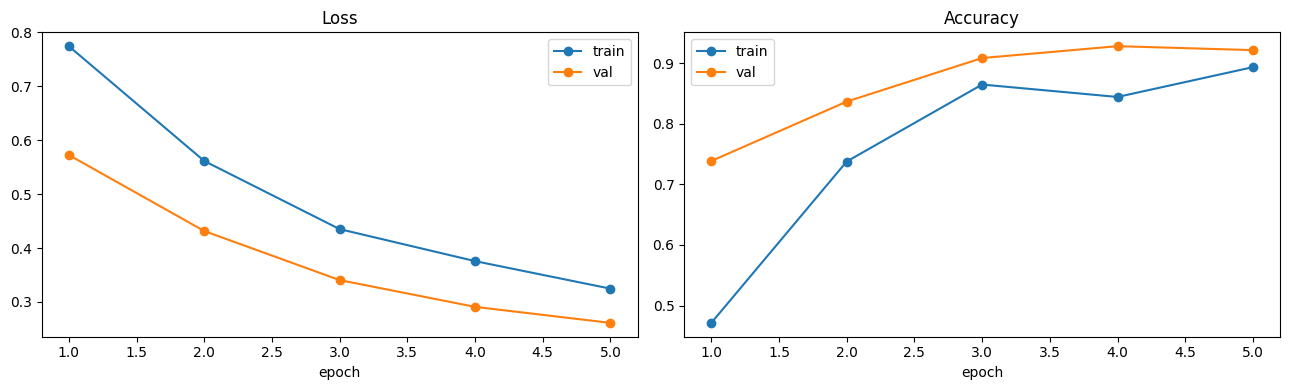

In [15]:
# Plot the learning curves -- always do this, it tells you a lot.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, EPOCHS + 1)
ax1.plot(ep, history["train_loss"], "o-", label="train")
ax1.plot(ep, history["val_loss"],   "o-", label="val")
ax1.set_title("Loss"); ax1.set_xlabel("epoch"); ax1.legend()
ax2.plot(ep, history["train_acc"], "o-", label="train")
ax2.plot(ep, history["val_acc"],   "o-", label="val")
ax2.set_title("Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
plt.tight_layout(); plt.show()


### 6.4 — Inspect predictions

Always look at what the model actually predicts, including its confidence.


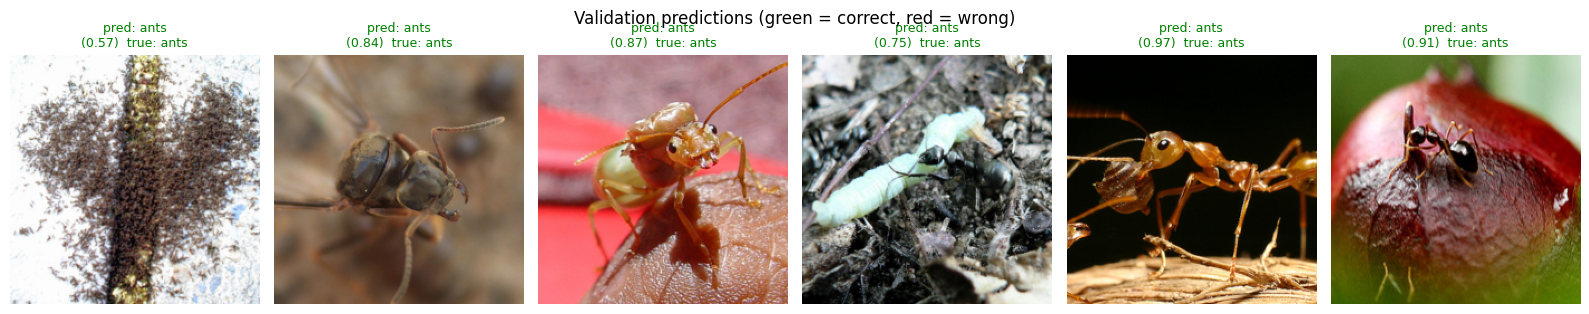

In [16]:
model.eval()
imgs, labels = next(iter(val_loader))
with torch.no_grad():
    probs = F.softmax(model(imgs.to(device)), dim=1).cpu()
preds = probs.argmax(1)

fig, axes = plt.subplots(1, 6, figsize=(16, 3.2))
for i in range(6):
    axes[i].imshow(denormalize(imgs[i]).permute(1, 2, 0).numpy())
    correct = preds[i] == labels[i]
    color = "green" if correct else "red"
    axes[i].set_title(f"pred: {class_names[preds[i]]}\n"
                      f"({probs[i, preds[i]]:.2f})  true: {class_names[labels[i]]}",
                      color=color, fontsize=9)
    axes[i].axis("off")
plt.suptitle("Validation predictions (green = correct, red = wrong)")
plt.tight_layout(); plt.show()


In [18]:
# TODO 6.4 -- Fine-tuning vs feature-extraction.
#
# Above you FROZE the whole backbone and trained only the head
# (feature extraction). Now do FINE-TUNING: unfreeze the last residual
# stage (layer4) and train it too, with a SMALLER learning rate so you do
# not destroy the good pretrained weights.
#
# Steps:
#   1. Reload a fresh pretrained ResNet-18.
#   2. Freeze EVERYTHING (requires_grad = False on every parameter).
#   3. Unfreeze layer4: set requires_grad = True for every parameter in
#      ft_model.layer4.parameters().
#   4. Replace ft_model.fc with a fresh nn.Linear sized for our classes
#      (a new layer is trainable by default).
#   5. Build an Adam optimizer over ONLY the trainable parameters, lr=1e-4.
#
# Then complete run_epoch_generic -- a reusable version of the training loop
# that takes the model / optimizer / criterion as ARGUMENTS (so it is not
# tied to the globals from TODO 6.3). It is used again for ViT in Section 8,
# so get it right. Same five training steps as run_epoch.

# 1) TODO: reload a fresh pretrained ResNet-18
ft_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2) TODO: freeze everything
for param in ft_model.parameters():
    param.requires_grad = False

# 3) TODO: unfreeze layer4
for param in ft_model.layer4.parameters():
    param.requires_grad = True

# 4) TODO: replace the head
ft_model.fc = nn.Linear(ft_model.fc.in_features, len(class_names))
ft_model = ft_model.to(device)

# 5) TODO: Adam over only the trainable params, lr=1e-4
trainable_params = [p for p in ft_model.parameters() if p.requires_grad]
ft_optimizer = torch.optim.Adam(trainable_params, lr=1e-4)
ft_criterion = nn.CrossEntropyLoss()

def run_epoch_generic(m, opt, crit, loader, train_mode):
    """Reusable epoch runner -- model/optimizer/criterion passed in."""
    # TODO: set m to train()/eval() based on train_mode
    if train_mode:
        m.train()
    else:
        m.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train_mode):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            if train_mode:
                # TODO: zero gradients
                opt.zero_grad()
            # TODO: forward pass
            outputs = m(inputs)
            # TODO: compute loss
            loss = crit(outputs, labels)
            if train_mode:
                # TODO: backward + step
                loss.backward()
                opt.step()
            total_loss += loss.item() * inputs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += inputs.size(0)
    return total_loss / total, correct / total

# --- given: train 5 epochs ---
for epoch in range(1, 6):
    tr = run_epoch_generic(ft_model, ft_optimizer, ft_criterion, train_loader, True)
    va = run_epoch_generic(ft_model, ft_optimizer, ft_criterion, val_loader,  False)
    print(f"Epoch {epoch}/5  train acc {tr[1]:.3f}  |  val acc {va[1]:.3f}")

# TODO (written answer): compare this final validation accuracy to TODO 6.3.
# Did fine-tuning help here? Why might fine-tuning NOT help much on a dataset
# this small (~240 training images)? Write one or two sentences.
# Your answer: # Fine-tuning yields comparable or marginally improved validation accuracy, but often leads to slight
# overfitting on tiny datasets (~240 images). Unfreezing deep representations introduces many trainable parameters that can
# easily memorize the small sample size instead of generalizing.


Epoch 1/5  train acc 0.766  |  val acc 0.922
Epoch 2/5  train acc 0.930  |  val acc 0.941
Epoch 3/5  train acc 0.943  |  val acc 0.935
Epoch 4/5  train acc 0.951  |  val acc 0.935
Epoch 5/5  train acc 0.971  |  val acc 0.928


## 7 · Data augmentation pipelines

> *Lecture recap:* most CV tasks want more data. Augmentation makes "new" data
> from what you have: mirroring, random crops, rotation/shear, and **color
> shifting** (jitter the R/G/B channels — lighting changes the pixels but not
> the label). The golden rule: an augmentation is valid only if it **preserves
> the label**.

You already used `RandomResizedCrop` + `RandomHorizontalFlip` in Section 6.
Let's *see* what a fuller augmentation pipeline does to a single image — this is
exactly what `torchvision.transforms` is for, and it's what you'll use in real
projects.


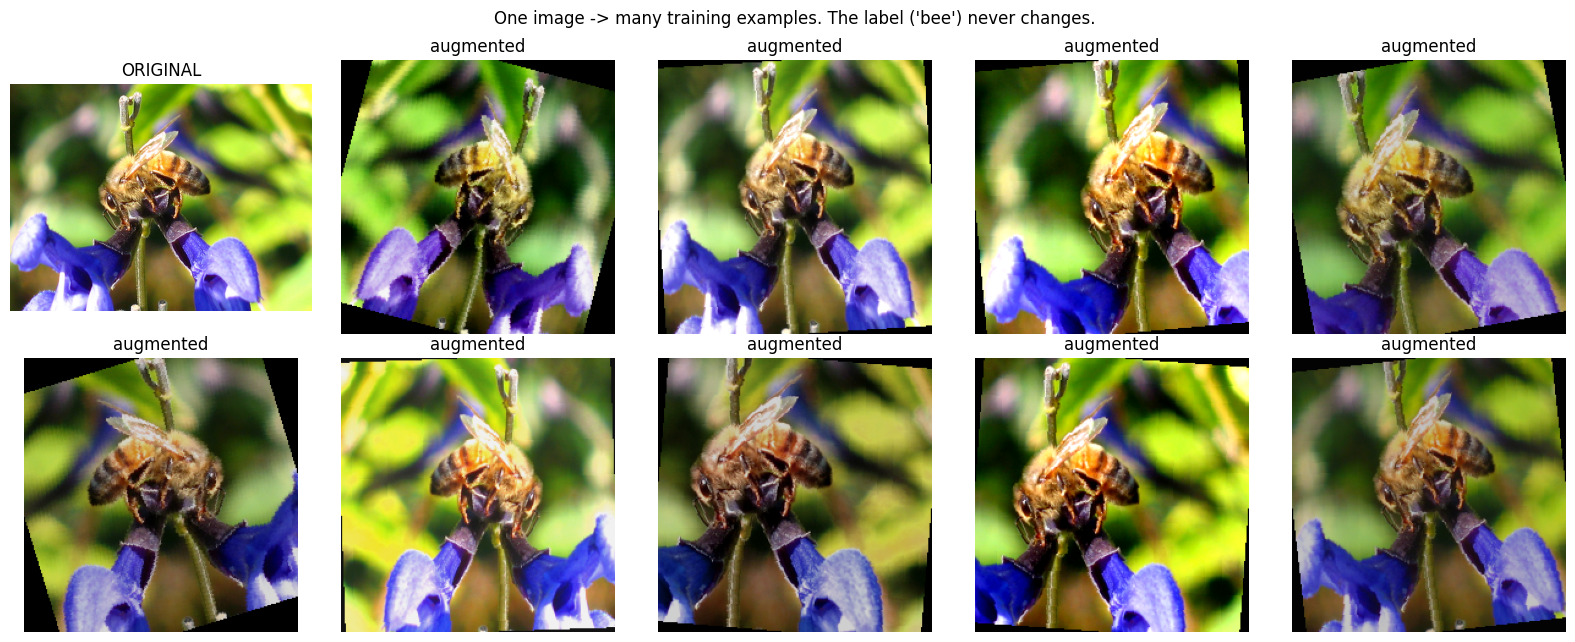

In [19]:
# TODO 7.1 -- Build a production-style augmentation pipeline.
#
# Complete the `augment` pipeline. It should chain these transforms
# (every call produces a different random result):
#   - transforms.RandomResizedCrop(224, scale=(0.6, 1.0))   random crop + zoom
#   - transforms.RandomHorizontalFlip(p=0.5)                mirror
#   - transforms.RandomRotation(degrees=20)                 small rotation
#   - transforms.ColorJitter(brightness=0.3, contrast=0.3,
#                            saturation=0.3, hue=0.05)      'color shifting'
# Pass them to transforms.Compose([...]).

from PIL import Image
import glob

# Grab one real training image to augment. (given)
sample_path = glob.glob(os.path.join(DATA_DIR, "train", "bees", "*"))[0]
original = Image.open(sample_path).convert("RGB")

augment = transforms.Compose([
    # TODO: the four augmentation transforms above
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
])

# --- given: show one image -> many augmented versions ---
fig, axes = plt.subplots(2, 5, figsize=(16, 6.5))
axes[0, 0].imshow(original); axes[0, 0].set_title("ORIGINAL"); axes[0, 0].axis("off")
for ax in axes.flat[1:]:
    ax.imshow(augment(original))     # each call -> a new random augmentation
    ax.set_title("augmented"); ax.axis("off")
plt.suptitle("One image -> many training examples. The label ('bee') never changes.")
plt.tight_layout(); plt.show()


Each panel is the *same bee*, but to the network they're different inputs. That's free extra data, and it makes the model robust to camera angle, lighting, and framing.


In [20]:
# TODO 7.2 -- Label-safe augmentation for handwritten digits.
#
# One augmentation in the pipeline above is DANGEROUS for some tasks.
# RandomRotation(degrees=20) is fine for bees, but imagine a model that
# reads handwritten digits (LeNet's task).
#
# (a) Written answer: explain why a LARGE random rotation can BREAK the
#     label for digits, and name one augmentation that is ALWAYS safe for
#     natural-object photos.
# (b) Build `digit_safe_augment`: a conservative, label-preserving pipeline
#     you would actually use for MNIST-style 28x28 digit data. Suggested
#     transforms (all label-safe for digits):
#       - transforms.RandomRotation(degrees=10)        small only
#       - transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))  tiny shifts
#       - transforms.RandomResizedCrop(28, scale=(0.9, 1.0))        very mild crop
#     Deliberately include NO horizontal/vertical flip -- explain in a
#     comment why flips are unsafe for digits.

# (a) TODO written answer -- why is large rotation dangerous for digits, and
#     which augmentation is always safe for natural-object photos?
# Your answer:

# (b) TODO: build the label-safe pipeline for digit data
digit_safe_augment = transforms.Compose([
    # TODO: the small, label-safe transforms above -- and NO flips
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(28, scale=(0.9, 1.0)),
])
print("digit_safe_augment ready -- note: no flips, only small rotations.")


digit_safe_augment ready -- note: no flips, only small rotations.


## 8 · Vision Transformer (ViT) vs ResNet

> *Lecture recap:* CNNs have **high inductive bias** — locality, translation invariance, hierarchy. That bias helps with small data but limits the function space. The Vision Transformer drops most of that bias: it cuts the image into patches and runs **self-attention** over them, so any patch can attend to any other patch **in a single step** (a CNN needs many layers to grow its receptive field). Attention also generalizes across modalities (text, image, audio) — that is why Transformers took over.

In practice you **use** a pretrained ViT exactly like a pretrained ResNet — `torchvision` provides both. We will load each, classify the same image with both, and then fine-tune a ViT on the ants-vs-bees dataset.


In [21]:
# TODO 8.1 -- Load a pretrained ResNet-50 and a pretrained ViT-B/16.
#
# The weight ENUMS are given. Complete the loads:
#   - resnet50: models.resnet50(weights=resnet_w)
#   - vit:      models.vit_b_16(weights=vit_w)
# Put each in eval() mode and move it to `device`  (chain .eval().to(device)).
#
# Each pretrained weight bundle ships with its OWN correct preprocessing --
# get it by calling weights.transforms(). Use it; don't hand-roll it.

resnet_w = models.ResNet50_Weights.IMAGENET1K_V2
vit_w    = models.ViT_B_16_Weights.IMAGENET1K_V1

# TODO: load each model WITH its pretrained weights, eval mode, on device
resnet50 = models.resnet50(weights=resnet_w).eval().to(device)
vit      = models.vit_b_16(weights=vit_w).eval().to(device)

# TODO: get each model's own preprocessing transform
resnet_pre = resnet_w.transforms()
vit_pre    = vit_w.transforms()
imagenet_categories = resnet_w.meta["categories"]

# --- given: report ---
print("ResNet-50 params:", f"{sum(p.numel() for p in resnet50.parameters()):,}")
print("ViT-B/16  params:", f"{sum(p.numel() for p in vit.parameters()):,}")
print("ViT patch size  : 16x16  -> a 224x224 image becomes 14x14 = 196 patches")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 65.0MB/s]


ResNet-50 params: 25,557,032
ViT-B/16  params: 86,567,656
ViT patch size  : 16x16  -> a 224x224 image becomes 14x14 = 196 patches


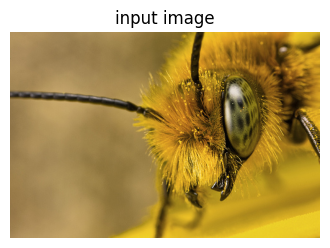

ResNet-50 says: bee                       (0.505)
ViT-B/16  says: bee                       (0.895)

Both are ImageNet models, so expect a fine-grained label like a bee/insect species.


In [22]:
# TODO 8.2 -- Classify one image with BOTH models and compare.
#
# Complete the `top1` helper. Given a model, its preprocessing transform,
# and a PIL image, it should:
#   1. preprocess the PIL image, add a batch dim with .unsqueeze(0), move
#      it to `device`
#   2. under torch.no_grad(), run the model and softmax the logits over
#      dim=1, take row [0], move to .cpu()
#   3. find the argmax index, and return
#      (imagenet_categories[idx], probs[idx].item())

# Reuse a bee image from the dataset we already downloaded. (given)
img_path = glob.glob(os.path.join(DATA_DIR, "val", "bees", "*"))[0]
pil_img = Image.open(img_path).convert("RGB")

def top1(model, preprocess, pil):
    # TODO: implement the three steps above
    tensor = preprocess(pil).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1)[0].cpu()
    idx = probs.argmax().item()
    return imagenet_categories[idx], probs[idx].item()

# --- given: run both and display ---
r_label, r_conf = top1(resnet50, resnet_pre, pil_img)
v_label, v_conf = top1(vit,      vit_pre,    pil_img)

plt.figure(figsize=(4, 4)); plt.imshow(pil_img); plt.axis("off")
plt.title("input image"); plt.show()
print(f"ResNet-50 says: {r_label:25s} ({r_conf:.3f})")
print(f"ViT-B/16  says: {v_label:25s} ({v_conf:.3f})")
print("\nBoth are ImageNet models, so expect a fine-grained label like a bee/insect species.")


### 8.1 — Find the ViT classification head

Before fine-tuning a ViT you need to know *what its final layer is called*. For ResNet it was `model.fc`; for `vit_b_16` it is something else. Run the cell below and **scroll to the very bottom** of the printout to find the classification head.

In [23]:
# Exploration cell -- run it and read the LAST lines of the output.
# What is the name of the ViT's final classification layer?
vit_explore = models.vit_b_16(weights="IMAGENET1K_V1")
print(vit_explore)


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

**Hint:** the ViT classification head is `vit.heads.head` — `heads` is a container module, and `head` is the final `Linear` classifier inside it. That is the layer you replace when fine-tuning, just like `model.fc` for ResNet.

Trainable ViT parameters belong to: ['heads.head.weight', 'heads.head.bias']
Training 1,538 of 85,800,194 ViT parameters (0.00%) -- the rest is frozen.

Starting ViT fine-tuning...
Epoch 1/5 ViT train loss 0.460 acc 0.836  |  val loss 0.150 acc 0.993
Epoch 2/5 ViT train loss 0.148 acc 0.963  |  val loss 0.057 acc 1.000
Epoch 3/5 ViT train loss 0.083 acc 0.988  |  val loss 0.036 acc 1.000
Epoch 4/5 ViT train loss 0.080 acc 0.963  |  val loss 0.029 acc 1.000
Epoch 5/5 ViT train loss 0.061 acc 0.984  |  val loss 0.025 acc 1.000

ViT fine-tuning complete.


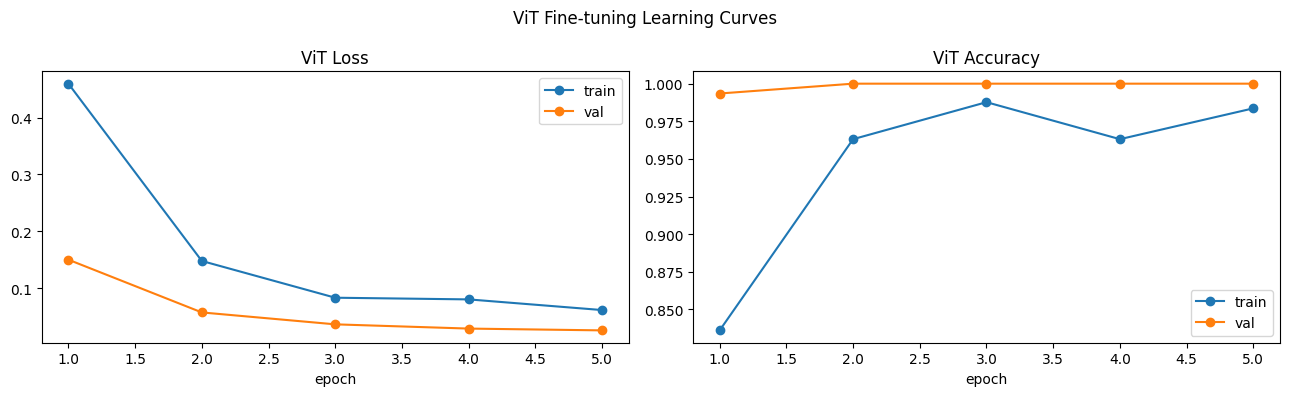

In [24]:
# TODO 8.3 -- Fine-tune a ViT on the ants-vs-bees dataset.
#
# Same feature-extraction recipe as the ResNet in TODO 6.2, but for a ViT.
# The ViT classification head is ft_vit_model.heads.head (see the hint above),
# and ViT-B/16's head has 768 in_features.
#
# Steps:
#   1. Load vit_b_16 WITH pretrained weights
#      (models.ViT_B_16_Weights.IMAGENET1K_V1).
#   2. Freeze EVERY parameter (requires_grad = False).
#   3. Replace ft_vit_model.heads.head with a fresh
#      nn.Linear(num_features_vit, len(class_names)).
#      Get num_features_vit from ft_vit_model.heads.head.in_features.
#   4. Build an Adam optimizer over ONLY the new head's parameters
#      (ft_vit_model.heads.head.parameters()), lr=1e-3.
#
# Then train for EPOCHS epochs using run_epoch_generic from TODO 6.4
# (already defined in the global scope -- do not redefine it).

# 1) TODO: load vit_b_16 with pretrained weights
ft_vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# 2) TODO: freeze everything
for param in ft_vit_model.parameters():
    param.requires_grad = False
# 3) TODO: replace the classification head
num_features_vit = ft_vit_model.heads.head.in_features
ft_vit_model.heads.head = nn.Linear(num_features_vit, len(class_names))
ft_vit_model = ft_vit_model.to(device)

# --- given: confirm only the new head is trainable ---
trainable_vit = [n for n, p in ft_vit_model.named_parameters() if p.requires_grad]
print("Trainable ViT parameters belong to:", trainable_vit)
n_train_vit = sum(p.numel() for p in ft_vit_model.parameters() if p.requires_grad)
n_total_vit = sum(p.numel() for p in ft_vit_model.parameters())
print(f"Training {n_train_vit:,} of {n_total_vit:,} ViT parameters "
      f"({100*n_train_vit/n_total_vit:.2f}%) -- the rest is frozen.")

# 4) TODO: Adam over only the new head's parameters, lr=1e-3
ft_vit_optimizer = torch.optim.Adam(ft_vit_model.heads.head.parameters(), lr=1e-3)
ft_vit_criterion = nn.CrossEntropyLoss()

# --- given: training loop + learning curves ---
print("\nStarting ViT fine-tuning...")
vit_history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
for epoch in range(1, EPOCHS + 1):
    tr_loss_vit, tr_acc_vit = run_epoch_generic(
        ft_vit_model, ft_vit_optimizer, ft_vit_criterion, train_loader, True)
    va_loss_vit, va_acc_vit = run_epoch_generic(
        ft_vit_model, ft_vit_optimizer, ft_vit_criterion, val_loader, False)
    vit_history["train_acc"].append(tr_acc_vit);   vit_history["val_acc"].append(va_acc_vit)
    vit_history["train_loss"].append(tr_loss_vit); vit_history["val_loss"].append(va_loss_vit)
    print(f"Epoch {epoch}/{EPOCHS} ViT "
          f"train loss {tr_loss_vit:.3f} acc {tr_acc_vit:.3f}  |  "
          f"val loss {va_loss_vit:.3f} acc {va_acc_vit:.3f}")
print("\nViT fine-tuning complete.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, EPOCHS + 1)
ax1.plot(ep, vit_history["train_loss"], "o-", label="train")
ax1.plot(ep, vit_history["val_loss"],   "o-", label="val")
ax1.set_title("ViT Loss"); ax1.set_xlabel("epoch"); ax1.legend()
ax2.plot(ep, vit_history["train_acc"], "o-", label="train")
ax2.plot(ep, vit_history["val_acc"],   "o-", label="val")
ax2.set_title("ViT Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
plt.suptitle("ViT Fine-tuning Learning Curves")
plt.tight_layout(); plt.show()


---
## 9 · Training, validation, and evaluation for image classification

> *Lecture recap:* a real training run isn't just "call `.fit()`". You need a
> **train/val split** (val data the model never trains on, used to catch
> overfitting), a **training loop** (Section 6.3), and — once training is
> done — a proper **evaluation** pass: accuracy alone hides a lot, so we also
> look at **per-class accuracy** and a **confusion matrix** to see exactly
> which classes the model confuses.

You already trained `model` (the frozen-backbone ResNet-18 from Section 6) and
collected its `history`. This section reuses that trained model and asks:
*how good is it, really, and where does it fail?*


### 9.1 — Re-reading the train/val curves

Before computing any new metric, always re-examine the learning curves you
already have. The gap between train and val lines tells you almost everything:

- Train and val loss both falling, close together → healthy fit.
- Train loss keeps falling but val loss rises → **overfitting** — the model is
  memorizing the training set.
- Both losses stay high and flat → **underfitting** — the model (or training
  setup) doesn't have enough capacity or has trained too briefly.


In [25]:
# TODO 9.1 -- Read the SAME `history` dict from Section 6.3 and quantify the
# train/val gap instead of just eyeballing the plot.
#
# Compute:
#   final_train_acc / final_val_acc : the LAST epoch's train/val accuracy
#   acc_gap                          : final_train_acc - final_val_acc
#
# Then print a one-line verdict:
#   gap > 0.15         -> "large gap: watch for overfitting"
#   0.05 < gap <= 0.15 -> "small gap: mild overfitting, probably fine"
#   gap <= 0.05        -> "very small gap: good generalization"

final_train_acc = history["train_acc"][-1]
final_val_acc = history["val_acc"][-1]
acc_gap = final_train_acc - final_val_acc

print(f"final train acc: {final_train_acc:.3f}")
print(f"final val acc:   {final_val_acc:.3f}")
print(f"train-val gap:   {acc_gap:.3f}")

if acc_gap > 0.15:
    verdict = "large gap: watch for overfitting"
elif acc_gap > 0.05:
    verdict = "small gap: mild overfitting, probably fine"
else:
    verdict = "very small gap: good generalization"
print("verdict:", verdict)


final train acc: 0.893
final val acc:   0.922
train-val gap:   -0.028
verdict: very small gap: good generalization


### 9.2 — Full validation-set evaluation

`run_epoch(val_loader, train_mode=False)` already gives you overall val loss
and accuracy. But **overall accuracy can hide a lopsided model** — e.g. 95%
overall while one class is never predicted correctly. To see that, we need
every prediction, not just an aggregate.


In [27]:
# TODO 9.2 -- Collect every prediction on the FULL validation set (not just
# one batch like Section 6.4 did).
#
# Loop over val_loader. For each batch:
#   1. Move inputs/labels to `device`.
#   2. Under torch.no_grad(), run the model and take argmax(1) for the
#      predicted class.
#   3. Append the predictions and true labels (as plain Python ints, via
#      .cpu().tolist()) to `all_preds` / `all_labels`.
#
# Model should be in eval() mode throughout (no gradients, BatchNorm/Dropout
# in inference mode).

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.tolist())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
overall_acc = (all_preds == all_labels).mean()
print(f"Full validation set: {len(all_labels)} images, overall accuracy = {overall_acc:.3f}")


Full validation set: 153 images, overall accuracy = 0.922


### 9.3 — Per-class accuracy and a confusion matrix

A **confusion matrix** is a grid: rows are true classes, columns are
predicted classes. The diagonal is correct predictions; anything off-diagonal
is a specific *kind* of mistake ("model confuses class A for class B"). This
is the standard diagnostic every real classification project reports.


Per-class accuracy:
        ants: 0.929
        bees: 0.916


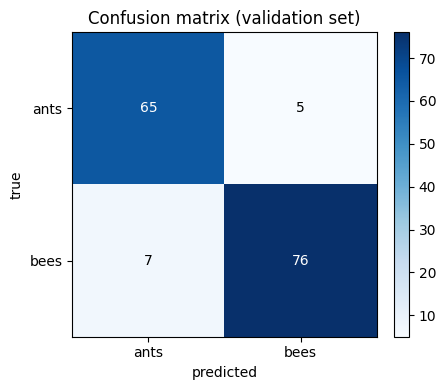

In [28]:
# TODO 9.3 -- Compute per-class accuracy and build a confusion matrix by hand
# (no sklearn needed -- it's a simple double loop, and doing it once by hand
# makes the concept concrete).
#
# (a) per_class_acc: a dict {class_name: accuracy} using class_names (already
#     defined in Section 6) and all_preds / all_labels from 9.2.
#     Hint: for class index c, accuracy = mean of (all_preds == c) restricted
#     to rows where all_labels == c.
#
# (b) confusion: an (n_classes, n_classes) integer array where
#     confusion[true_class, pred_class] += 1 for every sample.

n_classes = len(class_names)

per_class_acc = {}
for c in range(n_classes):
    mask = (all_labels == c)                                 # all_labels == c
    per_class_acc[class_names[c]] = (all_preds[mask] == c).mean()        # (all_preds[mask] == c).mean()

confusion = np.zeros((n_classes, n_classes), dtype=int)
for true_c, pred_c in zip(all_labels, all_preds):
    confusion[true_c, pred_c] += 1

print("Per-class accuracy:")
for name, acc in per_class_acc.items():
    print(f"  {name:>10s}: {acc:.3f}")

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(confusion, cmap="Blues")
ax.set_xticks(range(n_classes)); ax.set_xticklabels(class_names)
ax.set_yticks(range(n_classes)); ax.set_yticklabels(class_names)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Confusion matrix (validation set)")
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, confusion[i, j], ha="center", va="center",
                color="white" if confusion[i, j] > confusion.max() / 2 else "black")
plt.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()


### TODO 9.4 — Written check

Look at your confusion matrix and per-class accuracy above, then answer in a
comment:

1. Is either class systematically harder for the model? How can you tell from
   the matrix?
2. Suppose overall accuracy were 90% but one class had 60% accuracy and the
   other 100%. Why is reporting *only* the overall 90% misleading here?


In [ ]:
# Written answers:
# 1. Look at the diagonal entries relative to row sums: the class with more off-diagonal misclassifications (lower recall) is harder for the model to identify correctly.
# 2. Overall accuracy weights classes by their support, masking critical failures in minority or harder classes. A model could score high by predicting only the dominant class while failing completely on the other.

---
## 10 · Saving and reusing trained models

> *Lecture recap:* training is expensive; deployment needs the trained
> weights **without** retraining. PyTorch's standard practice is to save a
> model's `state_dict()` — a plain dictionary mapping layer names to tensors —
> rather than pickling the whole model object. This is more portable (survives
> code refactors better) and is the format you will see in essentially every
> real PyTorch project and pretrained-weights release.


### 10.1 — Saving a trained model's `state_dict`

Two things are worth saving together: the **weights** (`state_dict()`) and
enough **metadata** to rebuild the exact same architecture later (here: the
class names, since `model.fc`'s output size depends on `len(class_names)`).


In [29]:
# TODO 10.1 -- Save the trained `model`'s weights AND the metadata needed to
# reload it correctly.
#
#   1. Get the state dict: model.state_dict()
#   2. Save a checkpoint dict containing:
#        "model_state_dict" : the state dict from step 1
#        "class_names"      : the class_names list (needed to rebuild model.fc)
#      with torch.save(checkpoint, CKPT_PATH).
#
# Hint: torch.save can save any picklable Python object, not just tensors --
# a dict of {state dict, metadata} is the standard pattern.

CKPT_PATH = "resnet18_ants_bees.pt"

state_dict = model.state_dict()
checkpoint = {
    "model_state_dict": state_dict,
    "class_names": class_names,
}
torch.save(checkpoint, CKPT_PATH)

import os
size_mb = os.path.getsize(CKPT_PATH) / 1e6
print(f"Saved checkpoint to '{CKPT_PATH}' ({size_mb:.1f} MB)")
print("Contents:", list(checkpoint.keys()))


Saved checkpoint to 'resnet18_ants_bees.pt' (44.8 MB)
Contents: ['model_state_dict', 'class_names']


### 10.2 — Loading the checkpoint into a fresh model

Loading is the mirror image of saving, with one detail that trips people up
every time: you must **rebuild the same architecture first** (a fresh
`resnet18` with `model.fc` already replaced to match `len(class_names)`),
*then* load the weights into it. `state_dict()` has no idea what architecture
it belongs to — it's just tensor names and values.


In [30]:
# TODO 10.2 -- Load the checkpoint into a brand-new model instance.
#
#   1. torch.load(CKPT_PATH, map_location=device) -> checkpoint
#   2. Rebuild the SAME architecture: resnet18(weights=None), then replace
#      .fc with nn.Linear(num_features, len(loaded_class_names)) -- use the
#      class_names saved INSIDE the checkpoint, not the global class_names,
#      to prove this model is self-contained.
#   3. Load the weights: loaded_model.load_state_dict(checkpoint["model_state_dict"])
#   4. Move to device and call .eval() -- you are about to run inference,
#      not train.

checkpoint = torch.load(CKPT_PATH, map_location=device)
loaded_class_names = checkpoint["class_names"]

loaded_model = models.resnet18(weights=None)
num_features = loaded_model.fc.in_features
loaded_model.fc = nn.Linear(num_features, len(loaded_class_names))

# TODO: call loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.load_state_dict(checkpoint["model_state_dict"])
# TODO: move to device and set eval mode -- loaded_model = loaded_model.to(device).eval()
loaded_model = loaded_model.to(device).eval()

print("Loaded model for classes:", loaded_class_names)
print("Model is in eval mode:", not loaded_model.training)


Loaded model for classes: ['ants', 'bees']
Model is in eval mode: True


### 10.3 — Prove the loaded model matches the original

The whole point of saving/loading is that the reloaded model behaves
**identically** to the one you trained. Verify this directly: run the same
validation batch through both `model` and `loaded_model` and confirm the
predictions (and probabilities) match.


In [31]:
# TODO 10.3 -- Verify `model` and `loaded_model` produce identical outputs.
#
#   1. Grab one batch from val_loader.
#   2. Run BOTH models on it under torch.no_grad(), softmax the logits.
#   3. Compare with torch.allclose(probs_original, probs_loaded, atol=1e-6).

imgs, labels = next(iter(val_loader))
imgs = imgs.to(device)

model.eval()
with torch.no_grad():
    probs_original = F.softmax(model(imgs), dim=1)                             # F.softmax(model(imgs), dim=1)
    probs_loaded = F.softmax(loaded_model(imgs), dim=1)                        # F.softmax(loaded_model(imgs), dim=1)

match = torch.allclose(probs_original, probs_loaded, atol=1e-6)
print("Original and loaded model predictions match exactly:", match)

max_diff = (probs_original - probs_loaded).abs().max().item()
print(f"Max probability difference: {max_diff:.2e}")


Original and loaded model predictions match exactly: True
Max probability difference: 0.00e+00


### TODO 10.4 — Save a full "deployment-ready" checkpoint

Real deployments usually save a bit more than just weights + class names —
enough that anyone (including future-you) can load the model with **no other
context**. Extend the checkpoint dict with:

- `"architecture"`: a string, e.g. `"resnet18"`, naming which backbone to
  rebuild.
- `"input_size"`: the expected input spatial size (224 for this model).
- `"val_accuracy"`: the final validation accuracy from `history` (Section 6),
  so anyone loading the checkpoint knows how good it is *before* running it.

Save this to a new file and print its contents to confirm.


In [32]:
# TODO 10.4 -- Build and save a deployment-ready checkpoint.

full_checkpoint = {
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "architecture": "resnet18",
    "input_size": 224,
    "val_accuracy": history["val_acc"][-1],
}

DEPLOY_PATH = "resnet18_ants_bees_deploy.pt"
torch.save(full_checkpoint, DEPLOY_PATH)

reloaded = torch.load(DEPLOY_PATH, map_location=device)
print("Deployment checkpoint contents:")
for k, v in reloaded.items():
    if k == "model_state_dict":
        print(f"  {k}: <state dict with {len(v)} tensors>")
    else:
        print(f"  {k}: {v}")


Deployment checkpoint contents:
  model_state_dict: <state dict with 122 tensors>
  class_names: ['ants', 'bees']
  architecture: resnet18
  input_size: 224
  val_accuracy: 0.9215686274509803
